# Assignment 2

Deadline: 25.03.2025, 12:00 CET

- Marcel Blagotinšek, 25-744-202, marcel.blagotinsek@uzh.ch
- Lyuben Baltadzhiev, 25-739-046, lyubenmiroslavov.baltadzhiev@uzh.ch
- Michal Andrzejewski, 25-737-503, michalmaria.andrzejewski@uzh.ch
- Lorenzo Pagliani, 25-741-430, lorenzo.pagliani@uzh.ch
- Lorenzo Barbero, 25-743-709, lorenzo.barbero@uzh.ch

## 1. Linearization of Turnover

**(15 points)**

Turnover constraints are used to limit the amount of change in portfolio weights between periods, helping to manage transaction costs and maintain portfolio stability.

Your task is to implement a method `linearize_turnover_constraint` for the class `QuadraticProgram`, which modifies the quadratic programming problem to incorporate a linearized turnover constraint. This will involve updating the objective function coefficients, equality and inequality constraints, as well as the lower and upper bounds of the problem. 

Additionally, complete the example provided below to demonstrate that your method functions correctly.

In class, we discussed a solution that involved augmenting the dimensionality by a factor of three. Here, you are asked to implement an alternative method that involves a two-fold increase in dimensions. If you are unable to implement the two-fold method, you may proceed with the three-fold approach.

### Function Parameters:
- `x_init` (np.ndarray): The initial portfolio weights.
- `to_budget` (float, optional): The maximum allowable turnover. Defaults to `float('inf')`.

### Steps for Function Implementation:

As discussed in the lecture, introduce auxiliary variables and augment the matrices/vectors used for optimization.

- **Objective Function Coefficients**:  
  Pad the existing objective function coefficients (`P` and `q`) to accommodate the new variables introduced by the turnover constraint.  
  *Note*: "Padding" refers to adding extra elements (typically zeros) to an array or matrix to increase its size to a desired shape.

- **Equality Constraints**:  
  Pad the existing equality constraint matrix (`A`) to account for the new variables.

- **Inequality Constraints**:  
  Pad the existing inequality constraint matrix ('G') and vector ('h') and further add a new inequality constraint row to incorporate the turnover constraint.  

- **Lower and Upper Bounds**:  
  Pad the existing lower (`lb`) and upper (`ub`) bounds to accommodate the new variables.

- **Update Problem Data**:  
  Overwrite the original problem data in the `QuadraticProgram` class with the updated matrices and vectors to include the linearized turnover constraint.

In [25]:
# Import standard libraries
import types
import os
import sys

# Import third-party libraries
import numpy as np
import pandas as pd

# Import local modules
project_root = os.path.dirname(os.path.dirname(os.getcwd()))  # Change this path if needed
src_path = os.path.join(project_root, 'qpmwp-course\\src')
sys.path.append(project_root)
sys.path.append(src_path)
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.quadratic_program import QuadraticProgram
from helper_functions import load_data_msci

In [26]:
def linearize_turnover_constraint(self, x_init: np.ndarray, to_budget=float('inf')) -> None:
    '''
    Linearize the turnover constraint in the quadratic programming problem.

    This method modifies the quadratic programming problem to include a linearized turnover constraint.

    Parameters:
    -----------
    x_init : np.ndarray
        The initial portfolio weights.
    to_budget : float, optional
        The maximum allowable turnover. Defaults to float('inf').

    Notes:
    ------
    - The method updates the problem's objective function coefficients, inequality constraints,
    equality constraints, and bounds to account for the turnover constraint.
    - The original problem data is overridden with the updated matrices and vectors.

    Examples:
    ---------
    >>> qp = QuadraticProgram(P, q, G, h, A, b, lb, ub, solver='cvxopt')
    >>> qp.linearize_turnover_constraint(x_init=np.array([0.1, 0.2, 0.3]), to_budget=0.05)
    '''
    # Dimensions
    n = len(self.problem_data.get('q'))
    m = 0 if self.problem_data.get('G') is None else self.problem_data.get('G').shape[0]

    x_init = np.asarray(x_init).reshape(n)

    # Update the coefficients of the objective function
    P_old = self.problem_data.get('P')
    q_old = self.problem_data.get('q')

    P = np.block([
        [P_old, np.zeros((n, n))],
        [np.zeros((n, n)), np.zeros((n, n))]
    ])
    q = np.concatenate([q_old, np.zeros(n)])

    # Update the equality constraints
    A_old = self.problem_data.get('A')
    A = None if A_old is None else np.hstack([A_old, np.zeros((A_old.shape[0], n))])

    # Update the inequality constraints
    G_old = self.problem_data.get('G')
    h_old = self.problem_data.get('h')

    G_turn = np.vstack([
        np.hstack([ np.eye(n), -np.eye(n)]),
        np.hstack([-np.eye(n), -np.eye(n)]),
        np.hstack([np.zeros((1, n)), np.ones((1, n))])
    ])
    h_turn = np.concatenate([
        x_init,
        -x_init,
        np.array([to_budget])
    ])

    if G_old is None:
        G = G_turn
        h = h_turn
    else:
        G = np.vstack([
            np.hstack([G_old, np.zeros((m, n))]),
            G_turn
        ])
        h = np.concatenate([h_old, h_turn])

    # Update lower and upper bounds
    lb_old = self.problem_data.get('lb')
    ub_old = self.problem_data.get('ub')

    lb = np.concatenate([lb_old, np.zeros(n)])
    ub = np.concatenate([ub_old, np.repeat(np.inf, n)])

    # Override the original matrices (notice: b does not change)
    self.update_problem_data({
        'P': P,
        'q': q,
        'G': G,
        'h': h,
        'A': A,
        'lb': lb,
        'ub': ub,
    })

    return None

## Demo

#### Create P and q

In [27]:
# Load the msci country index data
N = 10
data = load_data_msci(path = '../data/', n=N)
X = data['return_series']

# Compute the vector of expected returns (mean returns)
q = ExpectedReturn(method='geometric').estimate(X=X, inplace=False)

# Compute the covariance matrix
P = Covariance(method='pearson').estimate(X=X, inplace=False)

# q, P

### Create some constraints, instantiate an object of class QuadraticProgram, and add the method linearize_turnover_constraint to the instance.

In [28]:
# Instantiate the constraints with only the budget and long-only constraints
constraints = Constraints(ids = X.columns.tolist())
constraints.add_budget(rhs=1, sense='=')
constraints.add_box(lower=0.0, upper=1.0)
GhAb = constraints.to_GhAb()

# Create a quadratic program and linearize the turnover constraint
qp = QuadraticProgram(
    P = P.to_numpy(),
    q = q.to_numpy() * 0,
    G = GhAb['G'],
    h = GhAb['h'],
    A = GhAb['A'],
    b = GhAb['b'],
    lb = constraints.box['lower'].to_numpy(),
    ub = constraints.box['upper'].to_numpy(),
    solver = 'cvxopt',
)

# Add the linearized turnover constraint method to the instance of class QuadraticProgram
qp.linearize_turnover_constraint = types.MethodType(linearize_turnover_constraint, qp)


### Add a turnover limit of 50%. Solve the problem and check whether the turnover constraint is respected.

In [29]:
# Prepare initial weights
x_init = pd.Series([1/X.shape[1]]*X.shape[1], index=X.columns)

# Add the linearized turnover constraint
qp.linearize_turnover_constraint(x_init=x_init, to_budget=0.5)

# Check the updated problem data dimensions (should be (2N, 2N))
qp.problem_data['P'].shape

# Solve the problem
qp.solve()

# Check the turnover
solution = qp.results.get('solution')
ids = constraints.ids
weights = pd.Series(solution.x[:len(ids)], index=ids)

print("Turnover:")
print(np.abs(weights - x_init).sum())


Turnover:
0.49954552248142015


## Appendix:

Below we also include the comparison with the solution without the turnover constraint.

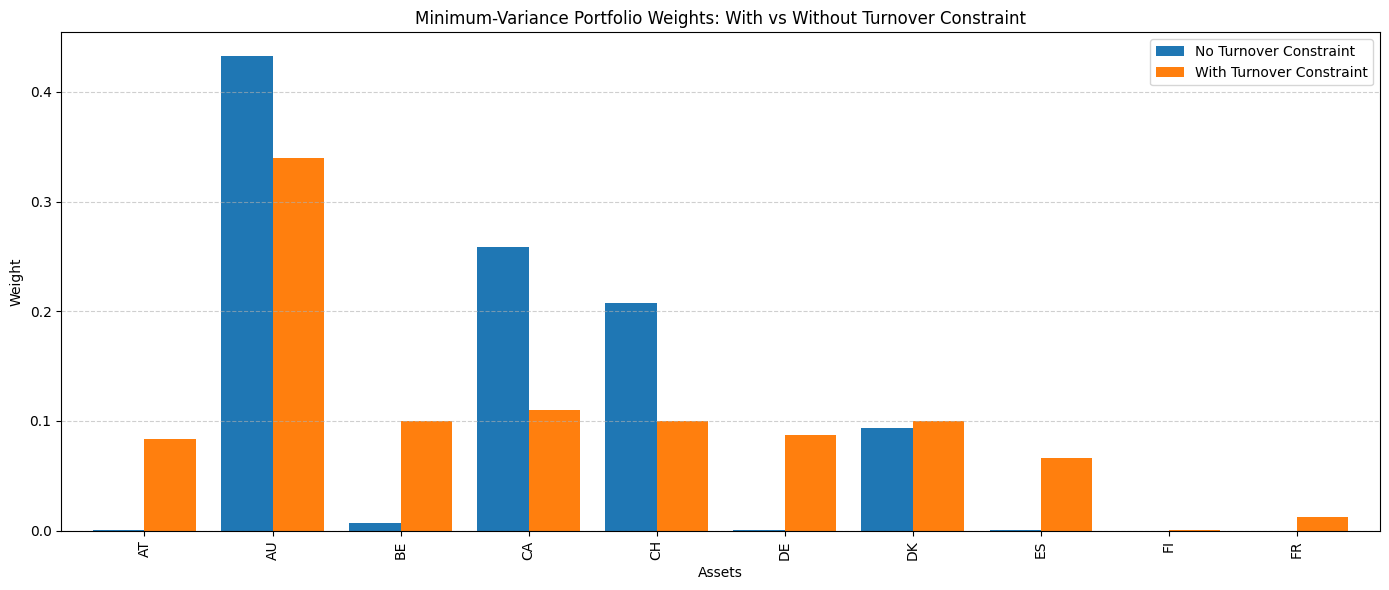


Weight comparison:
    No Turnover Constraint  With Turnover Constraint
AT                0.000268                  0.083745
AU                0.432613                  0.339312
BE                0.007045                  0.099931
CA                0.258765                  0.110309
CH                0.207532                  0.100086
DE                0.000102                  0.087477
DK                0.093368                  0.100066
ES                0.000175                  0.066566
FI                0.000047                  0.000339
FR                0.000085                  0.012170

Summary comparison:
          No Turnover Constraint  With Turnover Constraint
Turnover                1.197821                  0.499546
Risk                    0.008005                  0.008833


In [30]:
import matplotlib.pyplot as plt

# Compare minimum-variance portfolios with and without turnover constraint

# solve the same problem again, but wo the turnover constraint
qp_no_to = QuadraticProgram(
    P = P.to_numpy(),
    q = q.to_numpy() * 0,
    G = GhAb['G'],
    h = GhAb['h'],
    A = GhAb['A'],
    b = GhAb['b'],
    lb = constraints.box['lower'].to_numpy(),
    ub = constraints.box['upper'].to_numpy(),
    solver = 'cvxopt',
)

qp_no_to.solve()
solution_no_to = qp_no_to.results.get('solution')

weights_no_to = pd.Series(solution_no_to.x, index=constraints.ids, name='No Turnover Constraint')

# extract the weights from the turnover-constrained problem
solution_to = qp.results.get('solution')
weights_to = pd.Series(solution_to.x[:len(constraints.ids)], index=constraints.ids, name='With Turnover Constraint')

# compute turnover of both portfolios relative to x_init
turnover_no_to = np.abs(weights_no_to - x_init).sum()
turnover_to = np.abs(weights_to - x_init).sum()

# compute portfolio risk of both portfolios
Sigma = P.to_numpy()

risk_no_to = np.sqrt(weights_no_to.to_numpy() @ Sigma @ weights_no_to.to_numpy())
risk_to = np.sqrt(weights_to.to_numpy() @ Sigma @ weights_to.to_numpy())

var_no_to = weights_no_to.to_numpy() @ Sigma @ weights_no_to.to_numpy()
var_to = weights_to.to_numpy() @ Sigma @ weights_to.to_numpy()

# build comparison table
comparison_df = pd.DataFrame({
    'No Turnover Constraint': weights_no_to,
    'With Turnover Constraint': weights_to
})

# plot portfolio weights side by side
plt.figure(figsize=(14, 6))
comparison_df.plot(kind='bar', ax=plt.gca(), width=0.8)
plt.title('Minimum-Variance Portfolio Weights: With vs Without Turnover Constraint')
plt.xlabel('Assets')
plt.ylabel('Weight')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# summary
summary_df = pd.DataFrame({
    'No Turnover Constraint': [turnover_no_to, risk_no_to],
    'With Turnover Constraint': [turnover_to, risk_to]
}, index=['Turnover', 'Risk'])

print("\nWeight comparison:")
print(comparison_df)

print("\nSummary comparison:")
print(summary_df)
